<a href="https://colab.research.google.com/github/afan104/cell_image_models/blob/main/MaskRCNNCellsBrief.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Import libraries & Workspace setup
- install and import libraries
- set seed
- device agnostic code
- mount google drive and set working directory


In [1]:
%pip install distinctipy torchtnt torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 931.7/931.7 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 51.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-c

In [2]:
# Import Python Standard Library dependencies
import datetime
from functools import partial
from glob import glob
import json
import math
import multiprocessing
import os
from pathlib import Path
import random
from typing import Any, Dict, Optional
import sys

# Data manipulation and visualization libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from distinctipy import distinctipy
from PIL import Image, ImageDraw

# Import PyTorch dependencies
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
torchvision.disable_beta_transforms_warning()
from torchvision.tv_tensors import BoundingBoxes, Mask
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
import torchvision.transforms.v2  as transforms
from torchvision.transforms.v2 import functional as TF
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# Import Mask R-CNN
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2, MaskRCNN
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

# Import tqdm for progress bar
from tqdm.auto import tqdm

# Import pprint for displaying mAP values
from pprint import pprint

# Set options for Pandas DataFrame display
pd.set_option('max_colwidth', None)  # Do not truncate the contents of cells in the DataFrame
pd.set_option('display.max_rows', None)  # Display all rows in the DataFrame
pd.set_option('display.max_columns', None)  # Display all columns in the DataFrame

In [3]:
## Set random seed
seed = 1234
random.seed(seed)

In [4]:
# set up device agnostic code
device = "cuda" if torch.cuda.is_available() else 'cpu'
dtype = torch.float32
device, dtype

('cuda', torch.float32)

In [5]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

# change dir
os.chdir("/content/drive/MyDrive/Capaldi/MaskRCNNPrototype")

# import local utility functions
from utils import tensor_to_pil, stack_imgs

Mounted at /content/drive


# 1. Load in Data and Create Helper Functions
- Create dictionary of image paths {img1: path, img2: path, ...}
- Create mask dataframe (filename_index, PSversion, shapes, lineColor, fillColor, imageName, ImageHeight, ImageWidth)
- Get class names and colors
- Functions: 1) Generate bounding box function 2) create polygon mask

Get img_dict

In [6]:
# Create a dictionary that maps file names to file paths
project_dir = Path('/content/drive/MyDrive/Capaldi/MaskRCNNPrototype')
dataset_path = Path(f'{project_dir}/Data')

# Get a list of image files in the dataset
img_file_paths = list(dataset_path.glob('*.png'))
img_dict = {file.stem : file for file in img_file_paths}

Mask dataframe

In [7]:
import re
# create generator of json dataframes
annotation_file_paths = list(dataset_path.glob('*.json'))
mask_dataframes = (pd.read_json(f, orient='index').transpose() for f in tqdm(annotation_file_paths))

# concatenate into single dataframe
annotation_df = pd.concat(mask_dataframes, ignore_index=False)

# assign image filename as index
# annotation_df['index'] = annotation_df.apply(lambda row: row['imageName'].split('.')[0], axis = 1) # axis 1 applies on rows
annotation_df['index'] = annotation_df.apply(lambda row: re.split(r'[./]', row['imageName'])[-2], axis = 1) # axis 1 applies on rows, re.split splits on both . and / characters
annotation_df = annotation_df.set_index('index')

# keep rows that correspond to filenames in the img_dict
annotation_df = annotation_df.loc[list(img_dict.keys())]

  0%|          | 0/20 [00:00<?, ?it/s]

Get class_names

In [8]:
shapes_df = annotation_df['shapes'].explode().to_frame()

# apply to shapes column to convert to series (separate column)
shapes_df = shapes_df["shapes"].apply(pd.Series)

# get unique class names from shapes df
class_names = list(shapes_df["label"].unique())
class_names

# Preprend 'background' class
class_names.insert(0,'background')
class_names

# dict to convert from name to int
class_to_idx = {c:i for i,c in enumerate(class_names)}

get colors

In [9]:
# Generate a list of colors with a length equal to the number of labels
colors = distinctipy.get_colors(len(class_names))

# Make a copy of the color map in integer format
int_colors = [tuple(int(c*255) for c in color) for color in colors]

1) draw_bboxes function - Initialize partial function with no fill, and constant width, font, and font size.

2) create_polygon_mask function

In [10]:
import requests

# Set the name of the font file
font_file = 'KFOlCnqEu92Fr1MmEU9vAw.ttf'
url = f"https://fonts.gstatic.com/s/roboto/v30/{font_file}"

# Download the font file
if font_file in os.listdir():
  print(f"{font_file} already exists")
else:
  with open(font_file,"wb") as f:
    r = requests.get(url)
    f.write(r.content)
    print(f"{font_file} downloaded!")

draw_bboxes = partial(draw_bounding_boxes, fill=False, width=2, font=font_file, font_size=12)

KFOlCnqEu92Fr1MmEU9vAw.ttf already exists


In [11]:
# convert sgementation polygons to images
def create_polygon_mask(image_size, vertices):
    """
    Create a grayscale image with a white polygonal area on a black background.

    Parameters:
    - image_size (tuple): A tuple representing the dimensions (width, height) of the image.
    - vertices (list): A list of tuples, each containing the x, y coordinates of a vertex
                        of the polygon. Vertices should be in clockwise or counter-clockwise order.

    Returns:
    - PIL.Image.Image: A PIL Image object containing the polygonal mask.
    """

    # Create a new black image with the given dimensions
    mask_img = Image.new('L', image_size, 0)

    # Draw the polygon on the image. The area inside the polygon will be white (255).
    ImageDraw.Draw(mask_img, 'L').polygon(vertices, fill=(255))

    # Return the image with the drawn polygon
    return mask_img

# 2. Data Preparation
- A. Split 80-20 using skm

- B. Create custom dataset
  1. KoggClassifier subclassing Dataset
  2. Custom Transforms
  3. Create datasets & transfer to Dataloader

## A. Split 80-20

In [114]:
import sklearn.model_selection as skm

# Split files into test/train
file_IDs = list(img_dict.keys())
files_train, files_test = skm.train_test_split(file_IDs, train_size=0.8, test_size=0.2)

## B. Prepare Custom Dataset
  1. KoggClassifier subclassing Dataset
  2. Custom Transforms
  3. Create datasets & transfer to Dataloader

### B.1 Create KoggClassifier by subclassing Dataset

In [115]:
class KoggClassifier(Dataset):
  def __init__(self, img_keys, annotation_df, img_dict, class_to_idx, transforms = None):
    """
    Parameters:
        img_keys (list): List of unique identifiers for images.
        annotation_df (DataFrame): DataFrame containing the image annotations.
        img_dict (dict): Dictionary mapping image identifiers to image file paths.
        class_to_idx (dict): Dictionary mapping class labels to indices.
        transforms (callable, optional): Optional transform to be applied on a sample.
    """
    super().__init__()

    self.img_keys = img_keys
    self.annotation_df = annotation_df
    self.img_dict = img_dict
    self.class_to_idx = class_to_idx
    self.transforms = transforms

  def __len__(self):
    """
    Returns length of dataset.
    """
    return len(self.img_keys)
  def __getitem__(self, index):
    """
    Returns a tupel containing image and target annotations.
    """
    img_key = self.img_keys[index]
    annotation = self.annotation_df.loc[img_key]
    image, target = self.load_image_and_target(annotation)

    if self.transforms:
      image, target = self.transforms(image, target)

    return image, target
  def load_image_and_target(self, annotation):
    """
    Load image and its target from giving the annotation

    Parameters:
    annotation (pd.Series): image annotation

    Returns:
    Tuple containing image and dictionary with 'boxes' and 'labels'
    """
    # get image
    filepath = self.img_dict[annotation.name]
    image = Image.open(filepath).convert("RGB")

    # convert labels to indices
    labels = torch.Tensor(
        [self.class_to_idx[
            shape['label']
            ] for shape in annotation['shapes']]
    ).to(dtype=torch.int64)

    # get masks
    shape_points = [shape['points'] for shape in annotation['shapes']]
    all_shapes = [[tuple(p) for p in points] for points in shape_points]
    mask_imgs = [create_polygon_mask(image.size, shape) for shape in all_shapes]
    masks = Mask(torch.concat([Mask(transforms.PILToTensor()(mask_img), dtype=torch.bool) for mask_img in mask_imgs]))

    # get bounding boxes
    bboxes = BoundingBoxes(data=torchvision.ops.masks_to_boxes(masks), format='xyxy', canvas_size=image.size[::-1])

    return image, {'masks': masks,'boxes': bboxes, 'labels': labels}

### B.2 Create Custom Transforms

In [116]:
# Transforms for data aug
# Compose transforms for data augmentation
data_aug_tfms = transforms.Compose(
    transforms=[
        transforms.RandomIoUCrop(min_scale=0.3,
                             max_scale=1.0,
                             min_aspect_ratio=0.5,
                             max_aspect_ratio=2.0,
                             sampler_options=[0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
                             trials=400,
                             ),
        transforms.ColorJitter(
                brightness = (0.875, 1.125),
                contrast = (0.5, 1.5),
                saturation = (0.5, 1.5),
                hue = (-0.05, 0.05),
        ),
        transforms.RandomGrayscale(),
        transforms.RandomEqualize(),
        transforms.RandomPosterize(bits=3, p=0.5),
        transforms.RandomHorizontalFlip(p=0.5),
    ],
)

# Compose transforms to sanitize bounding boxes and normalize input data
final_tfms = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.SanitizeBoundingBoxes(),
])

# Define the transformations for training and validation datasets
train_tfms = transforms.Compose([
    data_aug_tfms,
    final_tfms
])
# valid_tfms is same as final_tfms

### B.3 Create Dataset

In [117]:
# Create a mapping from class names to class indices
class_to_idx = {c: i for i, c in enumerate(class_names)}

# Instantiate the datasets using the defined transformations
train_dataset = KoggClassifier(files_train, annotation_df, img_dict, class_to_idx, train_tfms)
valid_dataset = KoggClassifier(files_test, annotation_df, img_dict, class_to_idx, final_tfms)

Transfer to Dataloaders

In [118]:
# batch size
bs = 1

# workers
num_workers = multiprocessing.cpu_count()//2

# define collate function separately
def collate_fn(batch):
    """
    Collate function to be used with DataLoader.
    This function zips the images and targets separately.

    Parameters:
    batch (list): A list of tuples containing images and their corresponding targets.

    Returns:
    tuple: A tuple containing the images and targets.
    """
    return tuple(zip(*batch))


# Define parameters for DataLoader
data_loader_params = {
    'batch_size': bs,  # Batch size for data loading
    'num_workers': num_workers,  # Number of subprocesses to use for data loading
    'persistent_workers': True,  # If True, the data loader will not shutdown the worker processes after a dataset has been consumed once. This allows to maintain the worker dataset instances alive.
    'pin_memory': 'cuda' in device,  # If True, the data loader will copy Tensors into CUDA pinned memory before returning them. Useful when using GPU.
    'pin_memory_device': device if 'cuda' in device else '',  # Specifies the device where the data should be loaded. Commonly set to use the GPU.
    'collate_fn': collate_fn,
    #'collate_fn': lambda batch: tuple(zip(*batch)) # zip(*batch) zips the images and targets separately (img_1, img_2) & (target_1, target_2)
                                                    # tuple() converts the zipped batch into a readable tuple ( (img_1, img_2), (target_1, target_2) )
}

# Create DataLoader for training data. Data is shuffled for every epoch.
train_dataloader = DataLoader(train_dataset, **data_loader_params, shuffle=True)

# Create DataLoader for validation data. Shuffling is not necessary for validation data.
valid_dataloader = DataLoader(valid_dataset, **data_loader_params, shuffle = False)

# 3. Loading pretrained Model (COCO dataset)
- Initialize pretrained model
  - Freeze network and add final layer
  - replace box predictor and mask predictor (commented out for some reason?)
  - Note: different from tutorial

- Initialize model instance

In [119]:
# Initialize pretrained model weights
model = maskrcnn_resnet50_fpn_v2(pretrained=True)

# Replace box predictor/classifier
in_features_box = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_channels=in_features_box,
                                                  num_classes=len(class_names))

# Replace mask predictor
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_channels=in_features_mask,
                                                 dim_reduced = hidden_layer,
                                                  num_classes = len(class_names))

params = [p for p in model.parameters() if p.requires_grad]

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_V2_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth
100%|██████████| 177M/177M [00:02<00:00, 67.2MB/s]


In [120]:
# set device and datatype
model.to(device=device, dtype=dtype)
model.name = 'maskrcnn_resnet50_fpn_v2'

# 4. Fine-Tuning Model
- A. Training Loop
- B. Testing Loop
- C. Train Model

Train output format:

{'loss_classifier': tensor(1.0237, grad_fn=<NllLossBackward0>),
 'loss_box_reg': tensor(0.2639, grad_fn=<DivBackward0>),
 'loss_mask': tensor(1.4003, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>),
 'loss_objectness': tensor(5.4521, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>),
 'loss_rpn_box_reg': tensor(0.3700, grad_fn=<DivBackward0>)}

targets format:

[
  
  {"masks":Mask(torch.Tensor(torch.bool)),

  "boxes":BoundingBoxes(torch.Tensor(torch.
  float32)),

  "labels":torch.Tensor(int)},

 {repeat for item 2 in batch},

 ...

 ]

## A. Training Loop

In [19]:
def train_one_epoch(model, dataloader, device, optimizer, scaler=None):
  """
  """
  # train
  model.train()

  # loop over data
  for batch, (inputs, targets) in tqdm(enumerate(dataloader)):
    inputs = torch.stack(inputs).to(device)
    targets = [{k: v.to(device) if isinstance(v,torch.Tensor) else v for k,v in t.items()} for t in targets]

    # forward pass & loss
    loss_dict = model(inputs, targets) # train loss format
    losses = sum(loss for loss in loss_dict.values())

    # optimizer 0 grad
    optimizer.zero_grad()

    # Option 1: Scaler
    if scaler is not None:
      print('not yet implimented, try without scaler')
      sys.exit(0)

    # Option 2: backward pass & optimizer step
    else:
      losses.backward()
      optimizer.step()
    print(f"training losses: {losses}")

## B. Testing Loop

In [20]:
def get_map(maskrcnn_map, model_output, target_dict):
  """
  Parameters -
  :maskrcnn_map ( MeanAveragePrecision instance )
  :model_output ( List[Dict] with 1 item in List )
  :target_dict  ( List[Dict] with 1 item in List)

  Returns -
  tuple(segm mean avg precision, bbox mean avg precision) with 0.5 iou threshold
  """
  # reshape predictions for map calculation
  img_size = (1608, 1608)
  model_output[0]["masks"] = Mask(model_output[0]["masks"].type(torch.bool).squeeze(dim=1))
  model_output[0]['boxes']=BoundingBoxes(data=model_output[0]['boxes'], format = 'xyxy', canvas_size = img_size)

  maskrcnn_map.update(model_output,target_dict)
  return (maskrcnn_map.compute()['bbox_map_50'],maskrcnn_map.compute()['segm_map_50'])

In [21]:
def test_one_epoch(model, dataloader, device):
  """
  Parameters -
  :model (pyTorch model)
  :dataloader (batched data)
  :device (GPU or CPU)

  Returns -
  loss
  accuracy
  """
  # eval
  model.eval()

  # loop over data
  with torch.inference_mode():
    for batch, (inputs_raw, targets) in tqdm(enumerate(dataloader)):
      inputs = torch.stack(inputs_raw).to(device)
      targets = [{k: v.to(device) if isinstance(v,torch.Tensor) else v for k,v in t.items()} for t in targets]

      # forward pass
      pred = model(inputs)

      # accuracy
      maskrcnn_map = MeanAveragePrecision(box_format="xyxy", iou_type = tuple(["bbox","segm"]), class_metrics=True)
      maps = get_map(maskrcnn_map=maskrcnn_map,model_output=pred,target_dict=targets)
      print(f"test accuracy: {maps}")

## C. Training the Model and Save

In [121]:
# load old model
PATH = 'models/model_2025-03-13_06-24-45.pth'
model.load_state_dict(torch.load(PATH, weights_only=True, map_location=torch.device(device)))

<All keys matched successfully>

In [23]:
epochs = 2
optimizer = torch.optim.SGD(params=model.parameters(),
                            lr = 0.2)
# combine test and train loop
for epoch in range(epochs):
  train_one_epoch(model,train_dataloader,device,optimizer)
  test_one_epoch(model,valid_dataloader,device)

0it [00:00, ?it/s]

training losses: 2.314678907394409
training losses: 1.8665213584899902
training losses: 1.7599108219146729
training losses: 1.7183231115341187
training losses: 2.0557749271392822
training losses: 2.288696527481079
training losses: 1.8223334550857544
training losses: 2.3521053791046143
training losses: 2.065059185028076
training losses: 1.3656286001205444
training losses: 2.861135482788086
training losses: 1.7535679340362549
training losses: 2.1894848346710205
training losses: 1.8790857791900635
training losses: 2.0511605739593506
training losses: 2.288893699645996


0it [00:00, ?it/s]

test accuracy: (tensor(0.1527), tensor(0.2624))
test accuracy: (tensor(0.0156), tensor(0.0699))
test accuracy: (tensor(0.1576), tensor(0.1134))
test accuracy: (tensor(0.0053), tensor(0.0597))


0it [00:00, ?it/s]

training losses: 1.9062533378601074
training losses: 2.3124043941497803
training losses: 1.9342814683914185
training losses: 2.4121415615081787
training losses: 2.200382709503174
training losses: 1.9909448623657227
training losses: 2.62658429145813
training losses: 1.436591386795044
training losses: 2.4340076446533203
training losses: 2.8944175243377686
training losses: 2.087860107421875
training losses: 2.289668083190918
training losses: 2.1930429935455322
training losses: 1.9444782733917236
training losses: 1.909667730331421
training losses: 1.8718643188476562


0it [00:00, ?it/s]

test accuracy: (tensor(0.0463), tensor(0.1624))
test accuracy: (tensor(0.0002), tensor(0.0250))
test accuracy: (tensor(0.0950), tensor(0.1223))
test accuracy: (tensor(0.0020), tensor(0.0123))


In [25]:
# Saving our PyTorch model
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
MODEL_NAME = "".join(["model_", timestamp,".pth"])
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/model_2025-03-13_06-24-45.pth


# 5. Making Predictions Using the Model

note: file id = 'fz_173_t0_Nstarve_1' does incredibly well on model 'models/model_2025-03-13_06-24-45.pth'

In [162]:
def visualize_pred(model, img_dict, file_id="", test_img=""):
  """
  Parameters -
  :model - pytorch model
  :img_dict - dict of name, path pairs
  :file_id - string, if "" then random choice
  :test_img - optional image object, default is the original file_id image
  """
  # grab image
  file_id = file_id if file_id != "" else random.choice(img_dict.keys())
  path = img_dict[file_id]
  test_img = test_img if test_img != "" else Image.open(path).convert("RGB")

  # grab target annotations
  target_shape_points = [shape['points'] for shape in annotation_df.loc[file_id]['shapes']]
  target_all_shapes = [[tuple(p) for p in points] for points in target_shape_points]
  target_mask_imgs = [create_polygon_mask(test_img.size,shape) for shape in target_all_shapes]
  target_masks = Mask(torch.concat(
      [Mask(transforms.PILToTensor()(mask), dtype = torch.bool) for mask in target_mask_imgs]
  ))

  target_labels = [shape['label'] for shape in annotation_df.loc[file_id]['shapes']]
  target_bboxes = BoundingBoxes(data=torchvision.ops.masks_to_boxes(target_masks), format = 'xyxy', canvas_size = test_img.size[::-1])

  # model forward pass
  model.eval()
  model.to(device)
  input_tensor = transforms.Compose([transforms.ToImage(),
                                    transforms.ToDtype(torch.float32, scale = True)])(test_img)[None].to(device)
  with torch.inference_mode():
    model_output = model(input_tensor)

  # filter output
  threshold = 0.05
  scores_mask = model_output[0]['scores'] > threshold

  # get output bboxes and labels
  pred_bboxes = BoundingBoxes(model_output[0]['boxes'][scores_mask], format='xyxy',canvas_size=test_img.size[::-1])
  pred_labels = [class_names[int(label)] for label in model_output[0]['labels'][scores_mask]]

  # get output masks
  pred_scores = model_output[0]['scores']
  pred_masks_filtered = model_output[0]['masks'][scores_mask]
  pred_masks = torch.concat([Mask(torch.where(mask >= threshold, 1, 0), dtype = torch.bool) for mask in pred_masks_filtered])

  # colors
  target_colors = [int_colors[i] for i in [class_names.index(label) for label in target_labels]]
  pred_colors = [int_colors[i] for i in [class_names.index(label) for label in pred_labels]]

  # convert image to tensor
  img_tensor = transforms.PILToTensor()(test_img)

  # annotate image with GT masks and bounding boxes
  annotated_tensor_truemask = draw_segmentation_masks(image=img_tensor, masks = target_masks, alpha = 0.3, colors = target_colors)
  annotated_tensor_truemaskbox = draw_bboxes(image=annotated_tensor_truemask, boxes = target_bboxes, labels = target_labels, colors = target_colors)
  gt_annotated_test_img = tensor_to_pil(annotated_tensor_truemaskbox)

  # annotate image with prediction masks and bounding boxes
  annotated_tensor_predmask = draw_segmentation_masks(image=img_tensor, masks = pred_masks, alpha = 0.3, colors = pred_colors)
  annotated_tensor_predmaskbox = draw_bboxes(image=annotated_tensor_predmask,
                                boxes = pred_bboxes,
                                labels = [f"{label}\n{prob*100:.2f}%" for label, prob in zip(pred_labels, pred_scores)],
                                colors = pred_colors)
  pred_annotated_test_img = tensor_to_pil(annotated_tensor_predmaskbox)

  # visualize
  display(stack_imgs([gt_annotated_test_img, pred_annotated_test_img]))
  # summary print statements
  target_bboxes_text = ", ".join([f"{label}: {bbox}" for label, bbox in zip(target_labels, target_bboxes)])
  pred_bboxes_text = ", ".join([f"{label}: {bbox}" for label, bbox in zip(pred_labels, pred_bboxes)])
  confidence_scores = ", ".join([f"{label}:{score*100:.2f}%" for label, score in zip(pred_labels, pred_scores)])
  print(f"Target BBoxes: {target_bboxes_text}")
  print(f"Predicted BBoxes: {pred_bboxes_text}")
  print(f"Confidence Scores: {confidence_scores}")


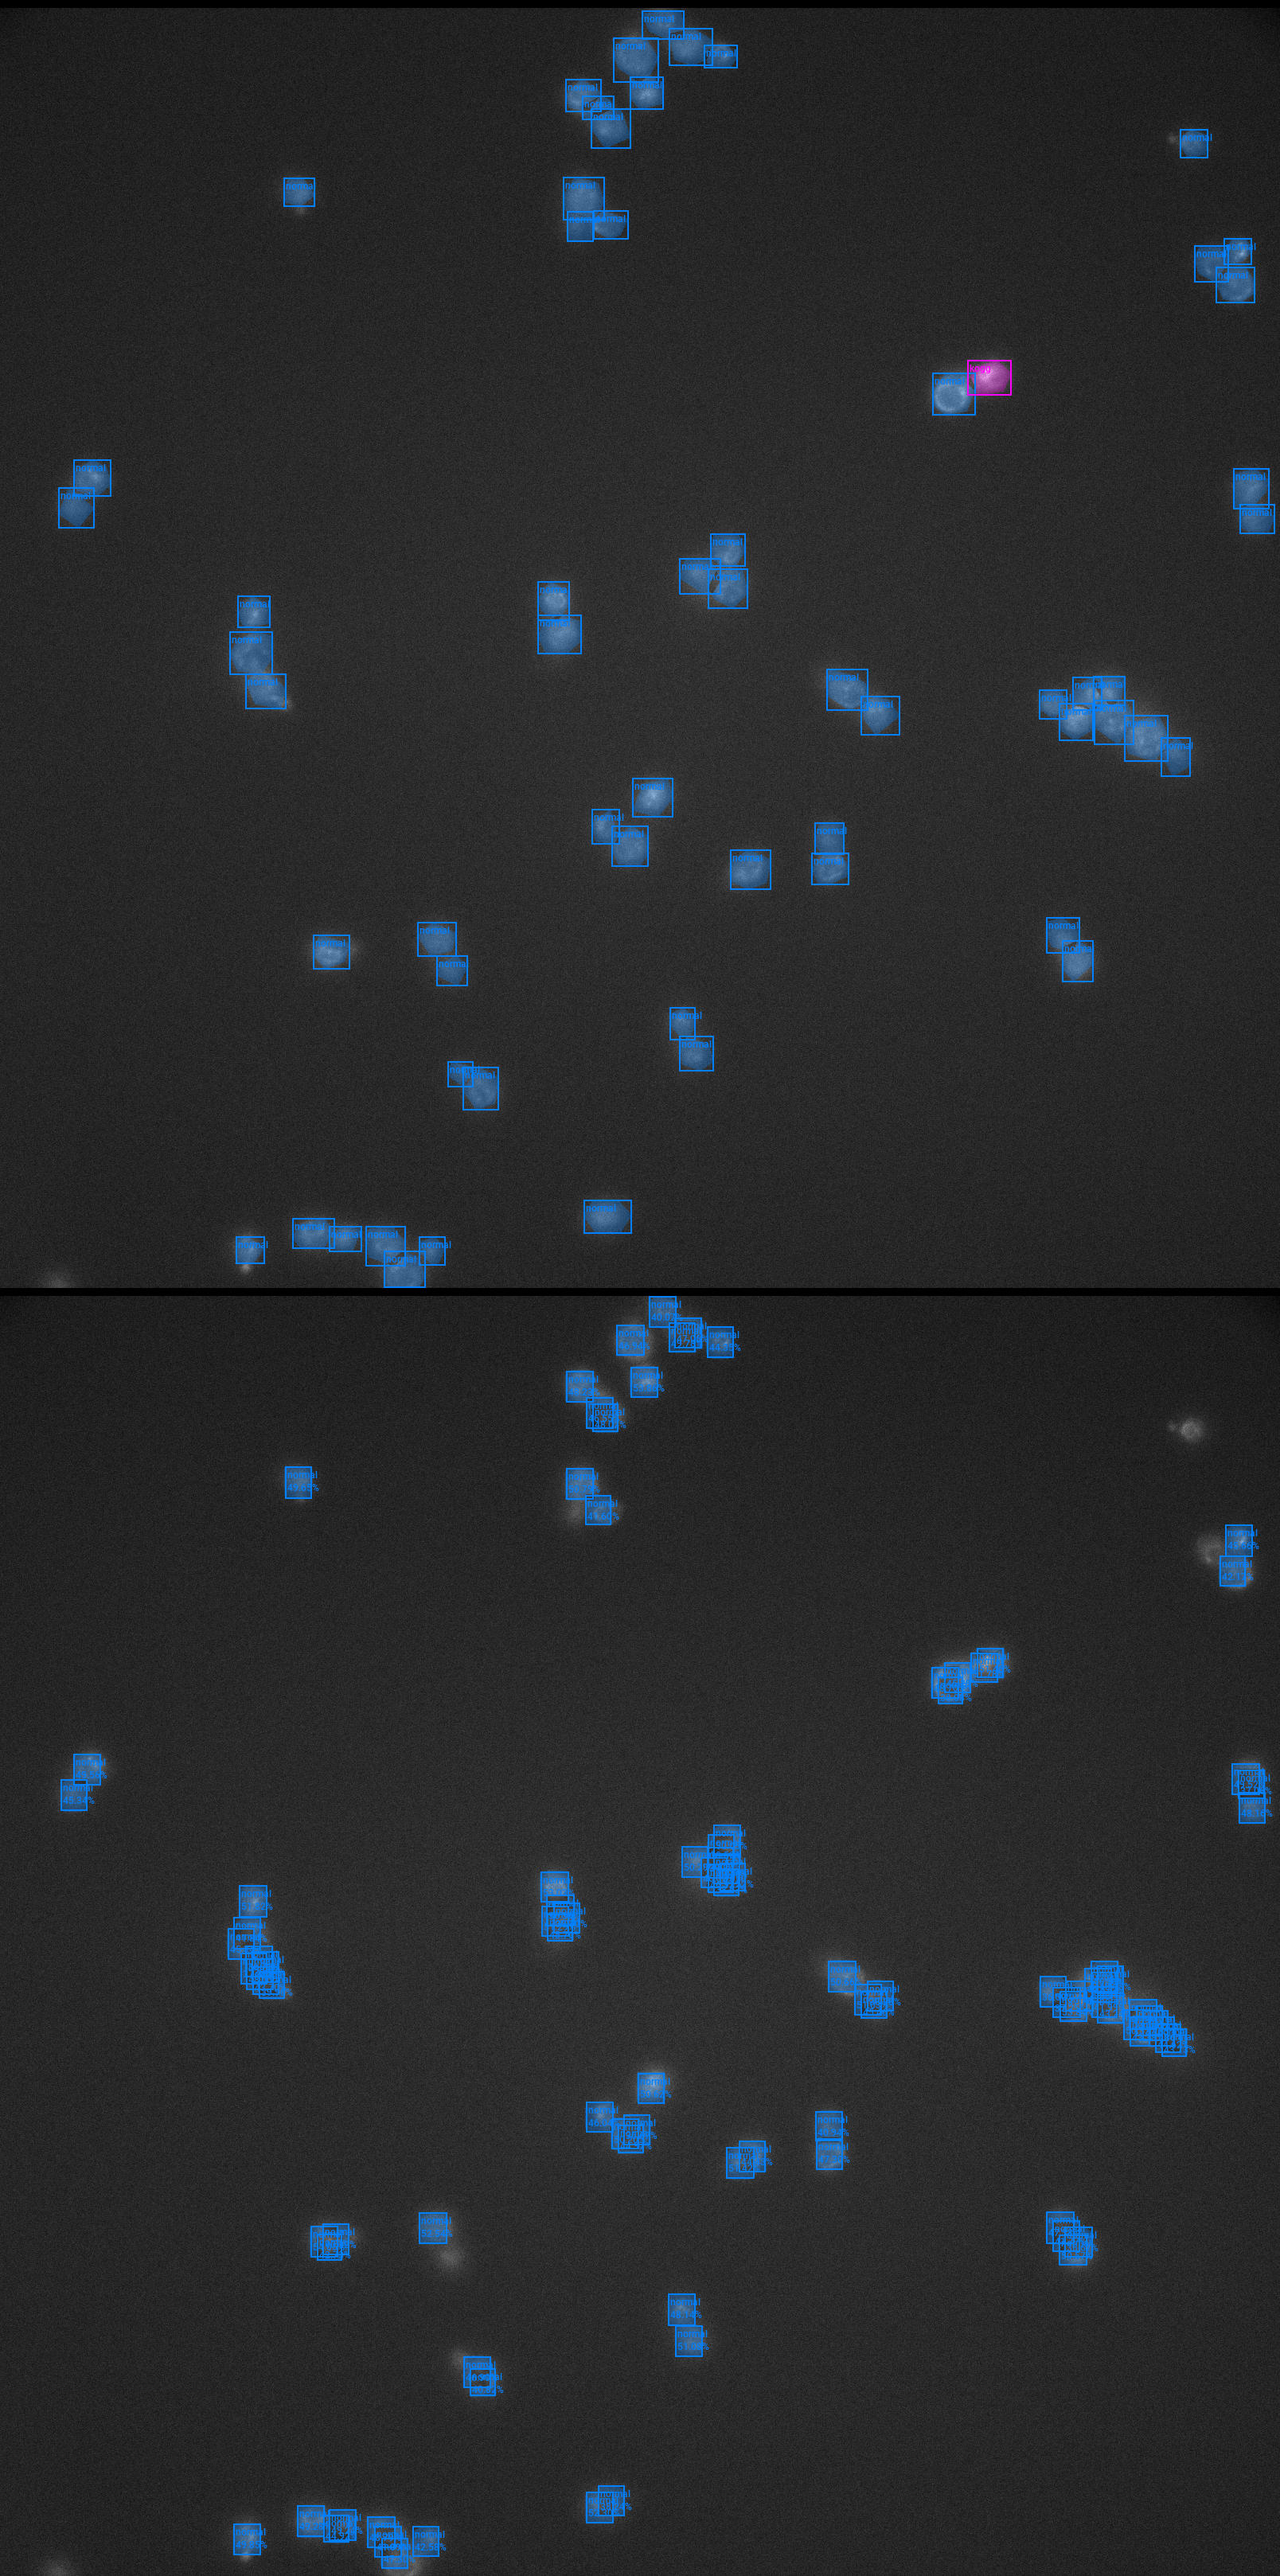

Target BBoxes: normal: tensor([ 92., 567., 139., 613.]), normal: tensor([ 73., 602., 118., 653.]), normal: tensor([298., 738., 339., 778.]), normal: tensor([288., 783., 342., 837.]), normal: tensor([308., 836., 359., 880.]), normal: tensor([356., 213., 395., 249.]), normal: tensor([ 393., 1164.,  439., 1207.]), normal: tensor([ 524., 1148.,  573., 1191.]), normal: tensor([ 548., 1190.,  587., 1228.]), normal: tensor([ 562., 1323.,  594., 1355.]), normal: tensor([ 581., 1330.,  626., 1384.]), normal: tensor([ 296., 1543.,  332., 1577.]), normal: tensor([ 367., 1520.,  420., 1558.]), normal: tensor([ 413., 1530.,  454., 1562.]), normal: tensor([ 482., 1561.,  534., 1607.]), normal: tensor([ 459., 1530.,  509., 1580.]), normal: tensor([ 526., 1543.,  559., 1579.]), normal: tensor([745., 254., 789., 290.]), normal: tensor([712., 255., 745., 293.]), normal: tensor([707., 212., 759., 266.]), normal: tensor([742., 126., 792., 176.]), normal: tensor([731., 110., 771., 140.]), normal: tensor([7

In [163]:
visualize_pred(model=model, img_dict=img_dict, file_id = 'fz_173_t0_Nstarve_1')

# 6. Preprocessing Images

In [85]:
# get the values for an image (1 dark that works poorly and 1 bright that works well)
name1 = 'fz_173_t0_AAstarve001_1'
path1 = '/content/drive/MyDrive/Capaldi/MaskRCNNPrototype/Data/fz_173_t0_AAstarve001_1.png'

name2 = 'fz_173_t0_Nstarve_1'
path2 = '/content/drive/MyDrive/Capaldi/MaskRCNNPrototype/Data/fz_173_t0_Nstarve_1.png'

img1 = Image.open(path1).convert("L")
img2 = Image.open(path2).convert("L")

In [179]:
# contrast algorithm
def custom_contrast(img, black_threshold, img_size):
  # get pixel values
  img.convert("L")
  gray_vals = list(img.getdata())

  # clamp lower than threshold to 0
  clamped_i = [i for i,x in enumerate(gray_vals) if x < black_threshold]

  # shift all others up so that median around 30
  shift = 30 - np.median(gray_vals)
  gray_vals += shift

  # clamp values above 255 and below threshold
  for i, x in enumerate(gray_vals): # above 255
    if x > 255:
      gray_vals[i] = 255
  for i in clamped_i: # below threshold
    gray_vals[i] = 0

  # create image object
  image_array = np.array(gray_vals, dtype=np.uint8).reshape(img_size)
  return Image.fromarray(image_array).convert("RGB")

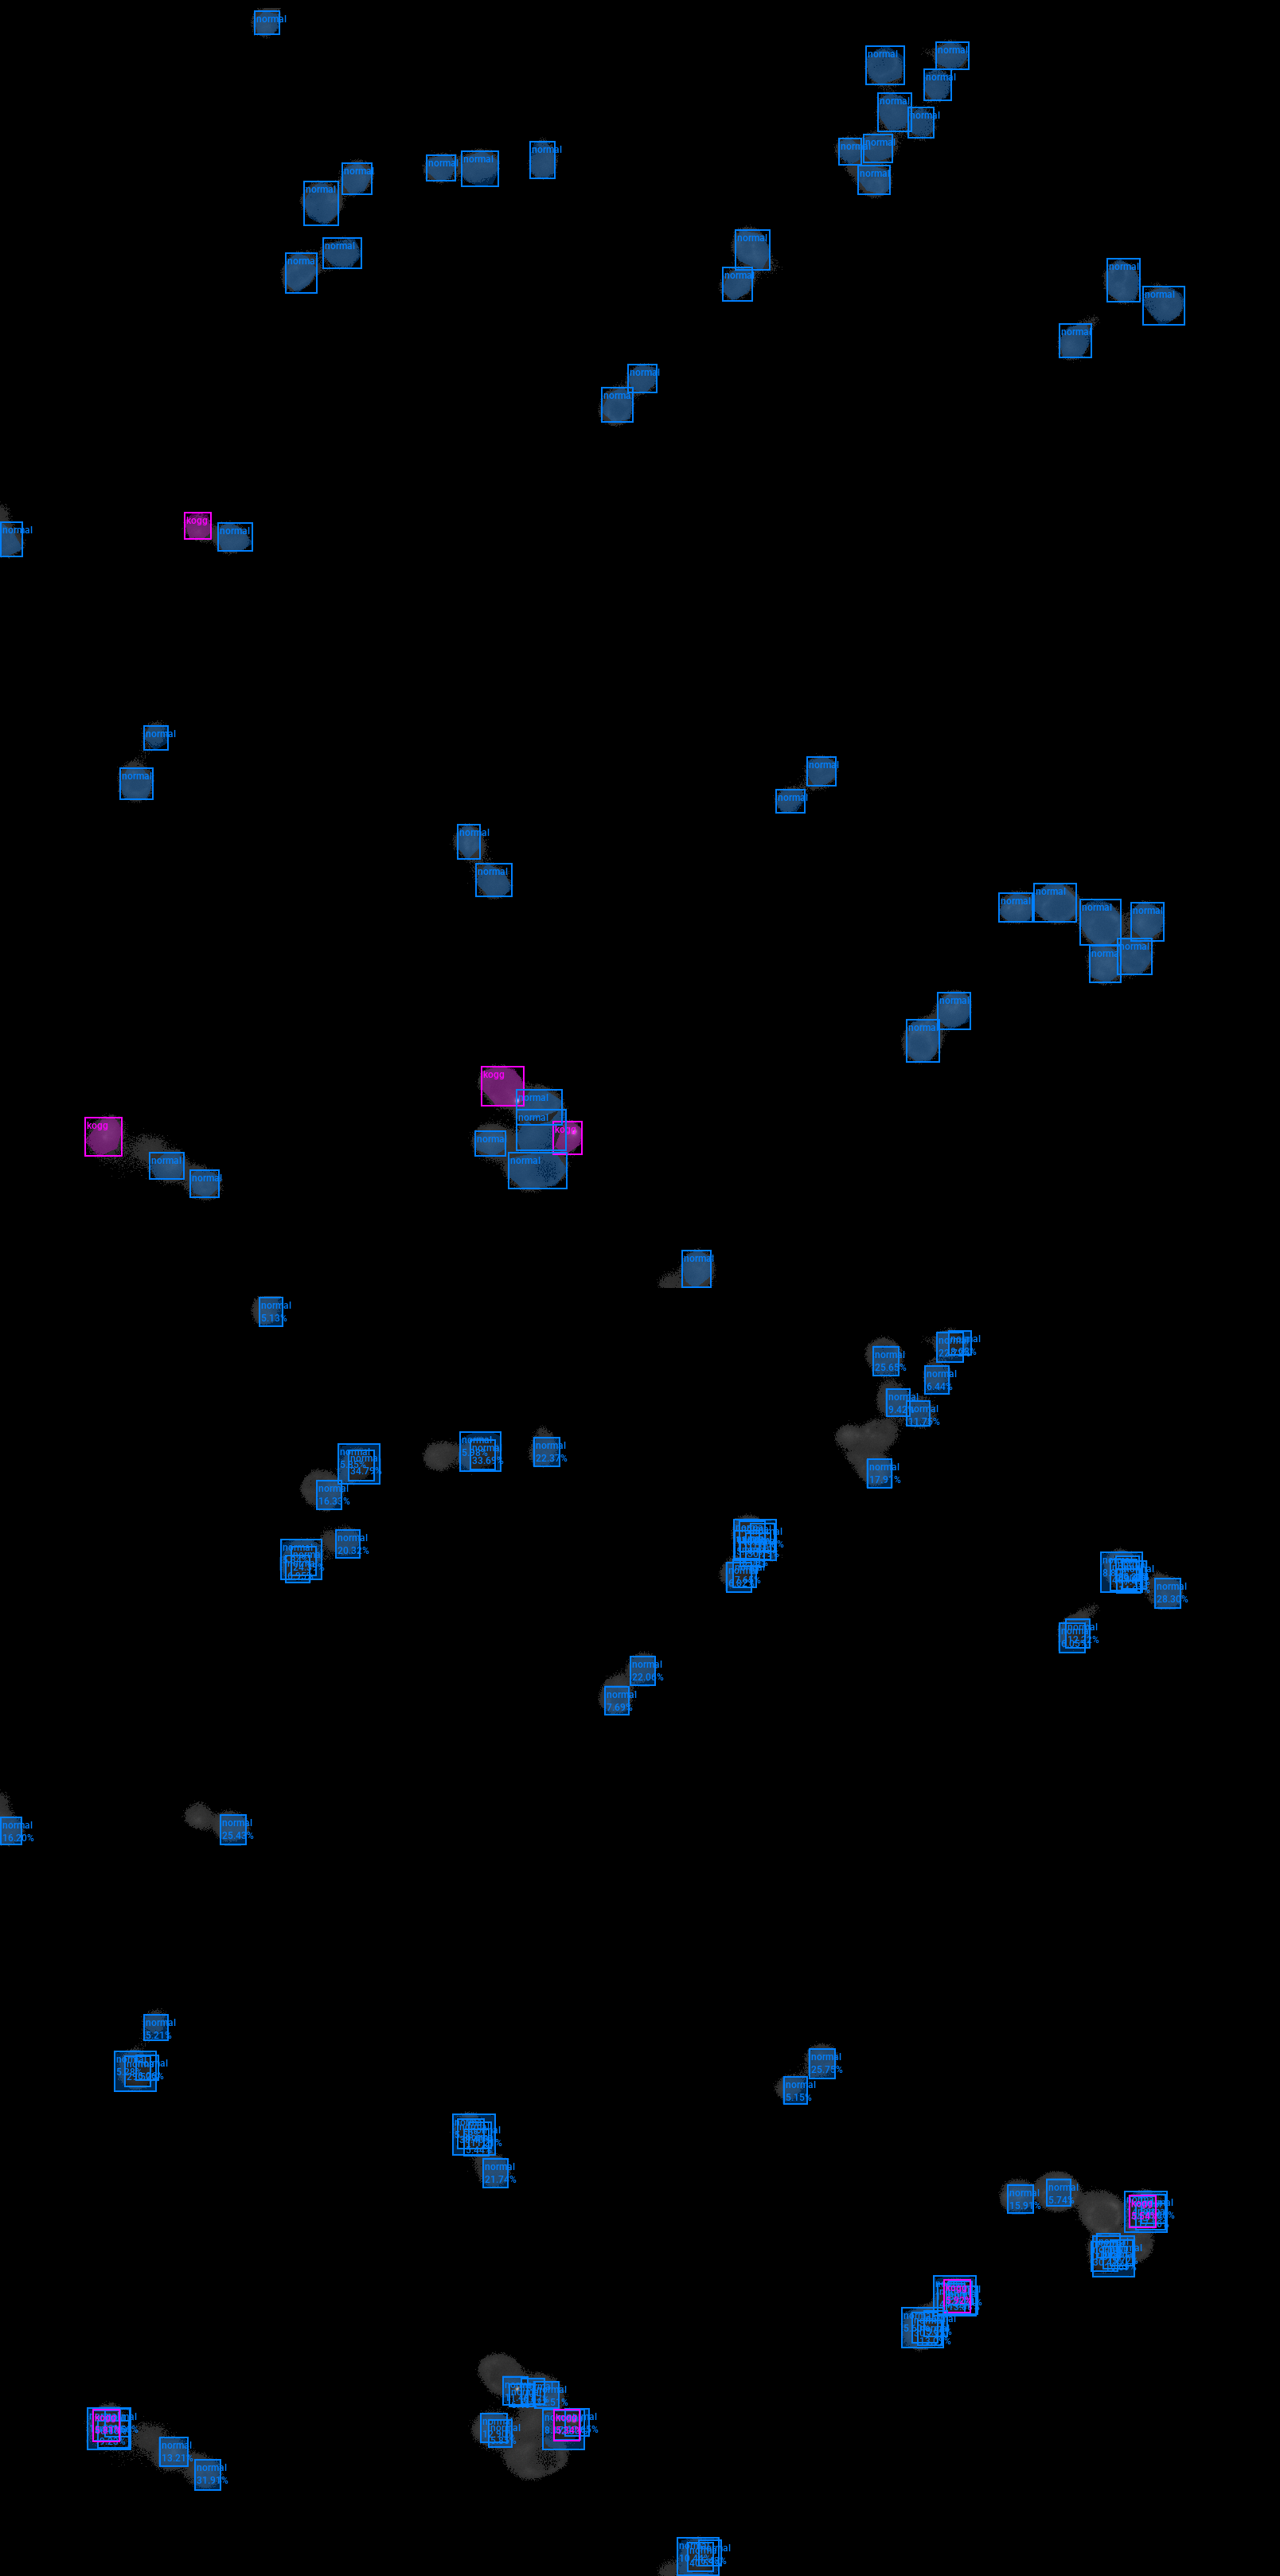

Target BBoxes: kogg: tensor([ 604., 1329.,  658., 1379.]), kogg: tensor([ 694., 1398.,  731., 1440.]), kogg: tensor([ 106., 1393.,  153., 1442.]), kogg: tensor([231., 633., 265., 667.]), normal: tensor([  0., 645.,  28., 689.]), normal: tensor([150., 954., 192., 994.]), normal: tensor([180., 901., 211., 932.]), normal: tensor([ 187., 1437.,  231., 1471.]), normal: tensor([ 238., 1459.,  275., 1494.]), normal: tensor([ 596., 1410.,  635., 1442.]), normal: tensor([ 638., 1437.,  712., 1483.]), normal: tensor([ 648., 1358.,  706., 1403.]), normal: tensor([273., 646., 317., 682.]), normal: tensor([319.,   3., 351.,  33.]), normal: tensor([429., 194., 467., 234.]), normal: tensor([381., 217., 425., 273.]), normal: tensor([405., 288., 454., 327.]), normal: tensor([358., 307., 398., 358.]), normal: tensor([535., 184., 572., 217.]), normal: tensor([579., 179., 626., 224.]), normal: tensor([665., 167., 697., 214.]), normal: tensor([ 574., 1025.,  603., 1069.]), normal: tensor([ 597., 1074.,  64

In [186]:
# compare predictions
new_img = custom_contrast(img1, 20, (1608,1608))
visualize_pred(model,img_dict,name1,new_img)